In [ ]:
## Data Generator

A custom TensorFlow Data Generator is used to load MRI scans and segmentation masks from HDF5 files in batches. This approach minimizes memory usage and enables efficient training on large medical imaging datasets. Each batch contains MRI images and their corresponding segmentation masks used for Deep U-Net training.

import tensorflow as tf
import h5py
import numpy as np
import os

class DataGenerator(tf.keras.utils.Sequence):

    def __init__(self, file_list, batch_size=8):

        self.file_list = file_list
        self.batch_size = batch_size

    def __len__(self):
        return len(self.file_list) // self.batch_size

    def __getitem__(self, idx):

        batch_files = self.file_list[
            idx*self.batch_size :
            (idx+1)*self.batch_size
        ]

        images = []
        masks = []

        for file_name in batch_files:

            path = os.path.join(data_path, file_name)

            with h5py.File(path, "r") as f:

                image = f["image"][:]
                mask = f["mask"][:]

            images.append(image)
            masks.append(mask)

        return (
            np.array(images, dtype=np.float32),
            np.array(masks, dtype=np.float32)
        )

In [ ]:
## Generator Testing

A sample batch is loaded from the custom data generator to verify that MRI images and segmentation masks are being processed correctly. The shapes of the input images and masks are displayed to confirm compatibility with the Deep U-Net architecture.

train_gen = DataGenerator(
    train_files,
    batch_size=4
)

x, y = train_gen[0]

print("X:", x.shape)
print("Y:", y.shape)

X: (4, 240, 240, 4)
Y: (4, 240, 240, 3)


In [ ]:
## Deep U-Net Architecture

The Deep U-Net model is designed for multi-class brain tumor segmentation using MRI scans. It follows an encoder-decoder architecture with skip connections that preserve important spatial information during training.

The encoder extracts hierarchical image features, while the decoder reconstructs detailed segmentation masks. The final output layer generates pixel-wise predictions for different tumor regions.


from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def conv_block(x, filters):

    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)

    return x


inputs = Input((240,240,4))

c1 = conv_block(inputs, 16)
p1 = MaxPooling2D()(c1)

c2 = conv_block(p1, 32)
p2 = MaxPooling2D()(c2)

c3 = conv_block(p2, 64)

u1 = UpSampling2D()(c3)
u1 = Concatenate()([u1,c2])

c4 = conv_block(u1,32)

u2 = UpSampling2D()(c4)
u2 = Concatenate()([u2,c1])

c5 = conv_block(u2,16)

outputs = Conv2D(
    3,
    1,
    activation="sigmoid"
)(c5)

model = Model(inputs, outputs)

model.summary()
### Model Summary

The model architecture consists of convolutional blocks, pooling layers, upsampling layers, and skip connections. The summary below provides details about the network structure, trainable parameters, and output dimensions.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 240, 240,  │        592 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 240, 240,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 120, 120,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 120, 120,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 120, 120,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 60, 60,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 60, 60,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 60, 60,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 120, 120,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 120, 120,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 120, 120,  │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 120, 120,  │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 240, 240,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 240, 240,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 240, 240,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 240, 240,  │      2,320 │ conv2d_8[0][0]  

 Total params: 118,451 (462.70 KB)

 Trainable params: 118,451 (462.70 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## Model Compilation

The model is compiled using the Adam optimizer and Binary Cross-Entropy loss function. Segmentation performance is evaluated using the Dice Coefficient, which measures the overlap between predicted masks and ground-truth tumor annotations.

Higher Dice scores indicate more accurate tumor segmentation.

import tensorflow as tf

def dice_coef(y_true, y_pred, smooth=1):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(y_true * y_pred)

    return (
        2. * intersection + smooth
    ) / (
        tf.keras.backend.sum(y_true)
        + tf.keras.backend.sum(y_pred)
        + smooth
    )

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[dice_coef]
)
## Dice Coefficient

The Dice Similarity Coefficient (DSC) is defined as:

\[
DSC = \frac{2|A \cap B|}{|A| + |B|}
\]

where:

- \(A\) = Ground Truth Mask
- \(B\) = Predicted Mask

The Dice Score ranges from 0 to 1, where 1 indicates perfect overlap between the predicted and actual segmentation masks.

In [ ]:
## Validation Dataset

A validation data generator is created to evaluate model performance on unseen MRI scans during training. This helps monitor generalization and prevent overfitting.

val_gen = DataGenerator(
    val_files,
    batch_size=4
)

Tumor sample found: 3


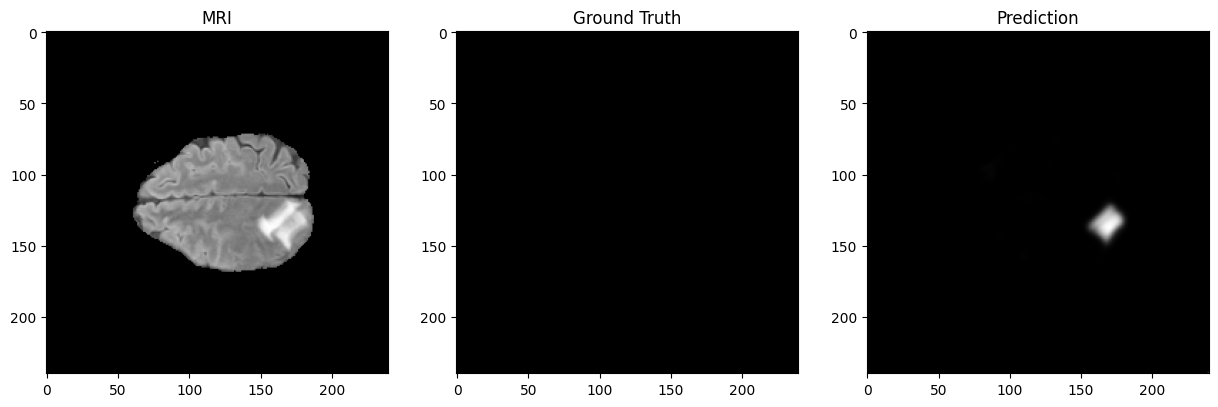

In [ ]:
## Segmentation Prediction Visualization

To evaluate the performance of the Deep U-Net model, a sample MRI scan containing a tumor is selected from the validation dataset.

Three visualizations are displayed side by side:

1. **MRI Scan** – Original brain MRI image.
2. **Ground Truth Mask** – Expert-annotated tumor segmentation mask.
3. **Predicted Mask** – Tumor region predicted by the Deep U-Net model.

This comparison helps assess how closely the model's predictions match the actual tumor boundaries.

### Why Three Images?

Displaying the MRI image, ground-truth mask, and predicted mask together provides a clear visual assessment of segmentation performance. It allows direct comparison between the actual tumor region and the model prediction, making it easier to identify strengths and potential segmentation errors.

import numpy as np

for i in range(4):

    if np.sum(sample_y[i]) > 0:

        print("Tumor sample found:", i)

        plt.figure(figsize=(15,5))

        plt.subplot(1,3,1)
        plt.imshow(sample_x[i][:,:,0], cmap="gray")
        plt.title("MRI")

        plt.subplot(1,3,2)
        plt.imshow(sample_y[i][:,:,0], cmap="gray")
        plt.title("Ground Truth")

        plt.subplot(1,3,3)
        plt.imshow(pred[i][:,:,0], cmap="gray")
        plt.title("Prediction")

        plt.show()

        break

In [ ]:
## Mask Analysis

The pixel sum of each segmentation mask channel is computed to verify the presence and size of tumor regions. This analysis helps confirm that the ground-truth masks contain valid annotations and provides insight into the distribution of different tumor subregions.

print("Mask sums")

print(np.sum(sample_y[i][:,:,0]))
print(np.sum(sample_y[i][:,:,1]))
print(np.sum(sample_y[i][:,:,2]))

Mask sums
0.0
659.0
0.0


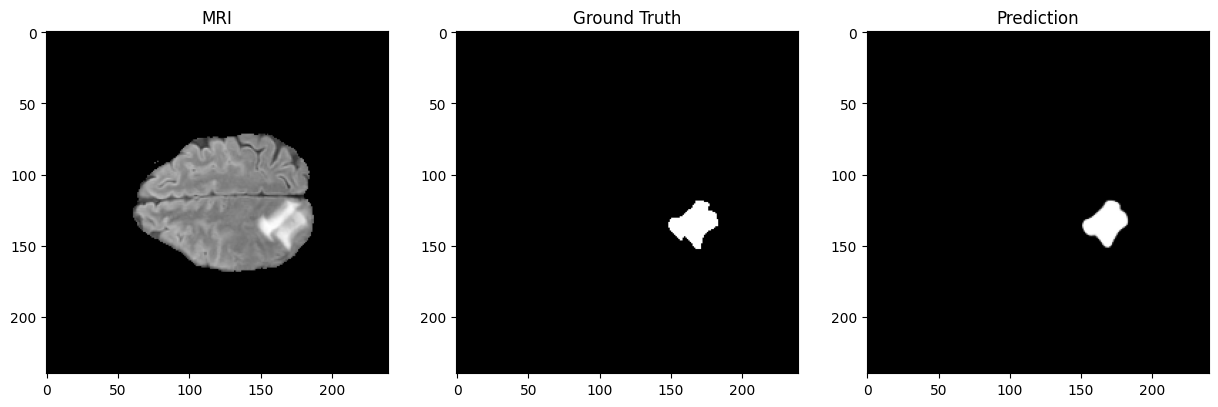

In [ ]:
## Segmentation Results

To evaluate the performance of the Deep U-Net model, a validation MRI slice is selected and compared against its corresponding ground-truth segmentation mask.

The visualization consists of three components:

1. **MRI Scan** – Original brain MRI image.
2. **Ground Truth Mask** – Expert-annotated tumor region.
3. **Predicted Mask** – Segmentation generated by the Deep U-Net model.

This side-by-side comparison provides a qualitative assessment of the model's ability to accurately identify tumor regions and reproduce the expert annotations.

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sample_x[i][:,:,0], cmap="gray")
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(sample_y[i][:,:,1], cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred[i][:,:,1], cmap="gray")
plt.title("Prediction")

plt.show()
### Tumor Region Visualization

For visualization purposes, Channel 1 of the segmentation mask is displayed. This channel represents one of the annotated tumor subregions used in the multi-class segmentation task. Comparing the ground-truth and predicted masks helps assess the model's localization accuracy.

In [ ]:
## Train-Validation Split

The dataset is divided into training and validation sets using an 80:20 ratio. This ensures that model performance can be evaluated on unseen MRI scans during training and helps monitor overfitting.

from sklearn.model_selection import train_test_split

all_files = [
    f for f in os.listdir(data_path)
    if f.endswith(".h5")
]

print("Total H5 files:", len(all_files))

train_files, val_files = train_test_split(
    all_files,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_files))
print("Val:", len(val_files))



Total H5 files: 57195
Train: 45756
Val: 11439


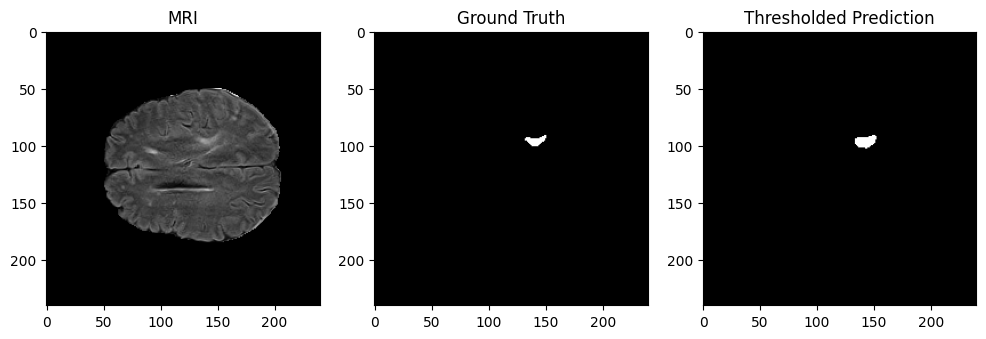

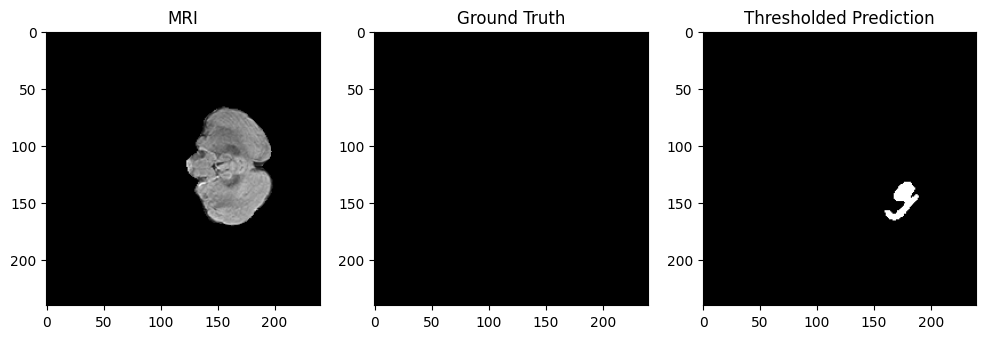

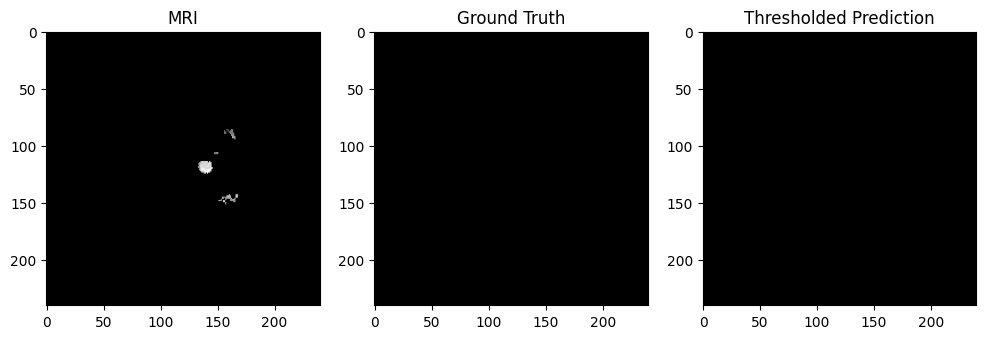

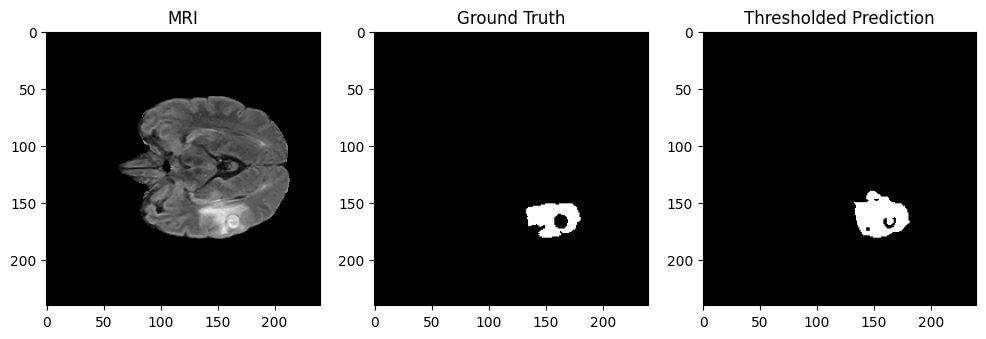

In [ ]:
## Thresholded Predictions

The predicted probability maps are converted into binary segmentation masks using a thresholding operation. This visualization compares the original MRI scan, ground-truth mask, and final thresholded prediction to evaluate segmentation quality.

import matplotlib.pyplot as plt

for i in range(4):

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(sample_x[i][:,:,0], cmap="gray")
    plt.title("MRI")

    plt.subplot(1,3,2)
    plt.imshow(sample_y[i][:,:,1], cmap="gray")
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(pred_bin[i][:,:,1], cmap="gray")
    plt.title("Thresholded Prediction")

    plt.show()

In [ ]:
## Dice Score Calculation

The Dice Similarity Coefficient (DSC) is computed to measure the overlap between the predicted tumor mask and the ground-truth annotation. A higher Dice Score indicates better segmentation performance and stronger agreement with expert-labeled tumor regions.

import numpy as np

intersection = np.sum(sample_y[:,:,:,1] * pred_bin[:,:,:,1])

dice = (2. * intersection) / (
    np.sum(sample_y[:,:,:,1]) +
    np.sum(pred_bin[:,:,:,1]) + 1e-7
)

print("Dice Score:", dice)

Dice Score: 0.69908196


In [ ]:
## Best and Worst Cases

The highest and lowest Dice Scores are identified from the evaluated samples. These values help assess the range of segmentation performance and highlight both successful predictions and challenging tumor cases.

print("Best:", max(dice_scores))
print("Worst:", min(dice_scores))

Best: (np.float64(0.9596022373946633), 'volume_93_slice_76.h5')
Worst: (np.float64(0.0), 'volume_93_slice_94.h5')
